<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_2_GAN_implementation_(Fashion).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ Cell 1: Environment Setup & GPU Configuration
Purpose: Prepares the workspace by importing libraries and ensuring we use the GPU (CUDA) for faster math.

import torch.nn as nn: The core toolkit for building neural network layers.

device = torch.device(...): Detects if an NVIDIA GPU is available.

Note: Vanilla GANs are mathematically simpler but still benefit greatly from GPU acceleration.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# ⚙️ Cell 2: Hyperparameters for Vanilla GAN
Purpose: Sets the dimensions and learning speeds.img_shape: For Vanilla GAN, we treat the 28x28 image as a flat vector of 784 numbers ($28 \times 28 = 784$).num_epochs: Fashion-MNIST is simple enough to show good results in 50 epochs.

In [ ]:
latent_dim = 100
img_size = 28
channels = 1
img_shape = (channels, img_size, img_size)
flat_shape = int(np.prod(img_shape)) # 784 pixels

batch_size = 128
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 50

# 🖼️ Cell 3: Loading Fashion-MNIST Data
Purpose: Downloads the dataset and normalizes it to the range [-1, 1].

In [ ]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

os.makedirs("fashion_results", exist_ok=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


# 🎨 Cell 4: The Vanilla Generator (Fully Connected)
Purpose: Unlike DCGAN, this uses simple nn.Linear layers to "stretch" noise into an image.

nn.Linear: A standard dense layer where every input connects to every output.

nn.LeakyReLU: Prevents neurons from "dying" by allowing small negative values.

nn.Tanh: Ensures the output pixels are between -1 and 1.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, flat_shape),
            nn.Tanh()
        )

    def forward(self, z):
        img_flat = self.model(z)
        img = img_flat.view(img_flat.size(0), *img_shape)
        return img

# 🕵️ Cell 5: The Vanilla Discriminator (The Detective)
Purpose: Analyzes the flattened image pixels to determine if they represent real clothing.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(flat_shape, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# 🧪 Cell 6: Initialization & Optimizers
Purpose: Creates the model instances and sets up the competition math.

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

# ⚔️ Cell 7: The Training Loop
Purpose: Trains the models and saves snapshots of clothing items as they are "invented."

In [ ]:
g_losses, d_losses = [], []

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}")):

        valid = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)
        real_imgs = imgs.to(device)

        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z)
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    # Save progress
    if (epoch + 1) % 10 == 0:
        save_image(gen_imgs.data[:25], f"fashion_results/epoch_{epoch+1}.png", nrow=5, normalize=True)
        print(f" [D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

Epoch 10/50: 100%|██████████| 469/469 [00:17<00:00, 26.94it/s]


 [D loss: 0.5647] [G loss: 0.6614]


Epoch 20/50: 100%|██████████| 469/469 [00:16<00:00, 28.29it/s]


 [D loss: 0.6615] [G loss: 1.0291]


Epoch 30/50: 100%|██████████| 469/469 [00:15<00:00, 30.68it/s]


 [D loss: 0.6668] [G loss: 1.1604]


Epoch 40/50: 100%|██████████| 469/469 [00:16<00:00, 27.89it/s]


 [D loss: 0.5866] [G loss: 0.8886]


Epoch 50/50: 100%|██████████| 469/469 [00:16<00:00, 29.21it/s]

 [D loss: 0.5758] [G loss: 1.0108]


# 📊 Cell 8: Final Visualization
Purpose: Displays the generated clothing items (boots, shirts, dresses).

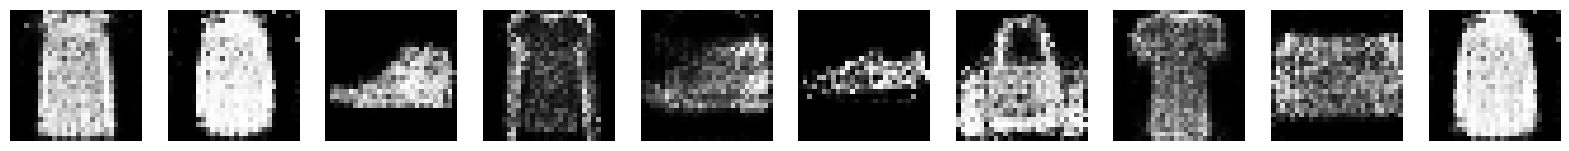

In [ ]:
def show_fashion():
    generator.eval()
    with torch.no_grad():
        z = torch.randn(10, latent_dim, device=device)
        gen_imgs = (generator(z).cpu() + 1) / 2
        fig, axes = plt.subplots(1, 10, figsize=(20, 4))
        for i in range(10):
            axes[i].imshow(gen_imgs[i].squeeze(), cmap='gray')
            axes[i].axis('off')
        plt.show()

show_fashion()